**Installs**

In [23]:
!pip install pandas==2.2.2 -q
!pip install statsforecast mlforecast neuralforecast utilsforecast lightgbm timecopilot -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 87.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tabpfn-time-series 1.0.3 requires pandas<2.2.0,>=2.1.2, but you have pandas 2.2.2 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
google-colab 1.0.0 requires tornado==6.5.1, but you have tornado 6.5.5 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.1.4 which is incompatible.
google-colab 1.0.0

**Imports**

In [24]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from mlforecast.lag_transforms import RollingMean

from statsforecast import StatsForecast
from statsforecast.models import Naive, SeasonalNaive, AutoETS, AutoARIMA

from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS, NHITS

from timecopilot import TimeCopilotForecaster
from timecopilot.models.foundation.chronos import Chronos

from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import bias, rmse, mae, mape

**Load Data**

In [25]:
df = pd.read_parquet('sample_hotels-1.parquet')

ts_df = (
    df[['unique_id', 'ds', 'y']]
    .assign(ds=lambda x: pd.to_datetime(x['ds']))
    .sort_values(['unique_id', 'ds'])
    .reset_index(drop=True)
)

ts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10172 entries, 0 to 10171
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   unique_id  10172 non-null  object        
 1   ds         10172 non-null  datetime64[us]
 2   y          10172 non-null  float64       
dtypes: datetime64[us](1), float64(1), object(1)
memory usage: 238.5+ KB


**EDA Plot**

In [26]:
plot_series(ts_df, engine='plotly')

**StatsForecast cross-validation**

In [27]:
sf = StatsForecast(
    models=[
        Naive(alias='Naive'),
        SeasonalNaive(season_length=7, alias='SeasonalNaive'),
        AutoETS(season_length=7, alias='AutoETS'),
        AutoARIMA(season_length=7, alias='AutoARIMA'),
    ],
    freq='D'
)

cv_sf = sf.cross_validation(
    df=ts_df,
    h=28,
    n_windows=5,
    step_size=28
)

**MLForecast**

In [28]:
# fill gaps in hotel_77 before MLForecast
def fill_gaps(df):
    full = []
    for uid, group in df.groupby('unique_id'):
        group = group.set_index('ds').asfreq('D').fillna(0).reset_index()
        group['unique_id'] = uid
        full.append(group)
    return pd.concat(full).reset_index(drop=True)

ts_df_filled = fill_gaps(ts_df)

ml = MLForecast(
    models={
        'LightGBM': LGBMRegressor(verbosity=-1)
    },
    freq='D',
    lags=list(range(28, 56)),
    lag_transforms={
        28: [
            RollingMean(window_size=7),
            RollingMean(window_size=14)
        ]
    },
    date_features=['month']
)

cv_ml = ml.cross_validation(
    df=ts_df_filled,
    h=28,
    n_windows=5,
    step_size=28,
    static_features=[]
)

**NeuralForecast cross-validation**

In [29]:
nf = NeuralForecast(
    models=[
        NBEATS(h=28, input_size=56, max_steps=100),
        NHITS(h=28, input_size=56, max_steps=100),
    ],
    freq='D'
)

cv_nf = nf.cross_validation(
    df=ts_df,
    h=28,
    n_windows=5,
    step_size=28
)

INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:lightning_fabric.utilities.seed:Seed set to 1
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
4.8 K     Non-trainable params
2.6 M     Total params
10.231    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


...

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

**TimeCopilot / Chronos CV**

In [30]:
tcf = TimeCopilotForecaster(
    models=[
        Chronos(repo_id="amazon/chronos-bolt-small"),
    ]
)

cv_chronos = tcf.cross_validation(
    df=ts_df,
    h=28,
    freq='D',
    n_windows=5,
    step_size=28
)

0it [00:00, ?it/s]
100%|██████████| 2/2 [00:00<00:00,  3.26it/s]
1it [00:00,  1.00it/s]
100%|██████████| 2/2 [00:00<00:00,  3.31it/s]
2it [00:01,  1.03it/s]
100%|██████████| 2/2 [00:00<00:00,  3.24it/s]
3it [00:02,  1.03it/s]
100%|██████████| 2/2 [00:00<00:00,  3.12it/s]
4it [00:03,  1.03it/s]
100%|██████████| 2/2 [00:00<00:00,  2.96it/s]
5it [00:04,  1.01it/s]


**Merge All CV Results**

In [31]:
merge_cols = ['unique_id', 'ds', 'cutoff', 'y']

cv_all = (
    cv_sf
    .merge(cv_ml[merge_cols + ['LightGBM']], on=merge_cols, how='left')
    .merge(cv_nf[merge_cols + ['NBEATS', 'NHITS']], on=merge_cols, how='left')
    .merge(cv_chronos[merge_cols + ['Chronos']], on=merge_cols, how='left')
)

print(cv_all.columns.tolist())
print(cv_all.shape)

['unique_id', 'ds', 'cutoff', 'y', 'Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA', 'LightGBM', 'NBEATS', 'NHITS', 'Chronos']
(2660, 12)


**Evaluate**

In [33]:
models = ['Naive', 'SeasonalNaive', 'AutoETS', 'AutoARIMA', 'LightGBM', 'NBEATS', 'NHITS', 'Chronos']

eval_results = (
    evaluate(
        df=cv_all,
        metrics=[bias, mae, rmse, mape],
        models=models
    )
    .drop(columns=['cutoff'])
    .groupby(['unique_id', 'metric'])
    .mean()
    .reset_index()
)

print(eval_results)

# Save using numpy instead of pandas csv writer
import csv
with open('cv_evaluation_results.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(eval_results.columns.tolist())
    for row in eval_results.itertuples(index=False):
        writer.writerow(row)
print('saved')

    unique_id metric     Naive  SeasonalNaive   AutoETS  AutoARIMA  LightGBM  \
0     hotel_0   bias  0.082011       0.029806 -0.007384   0.052847  0.041899   
1     hotel_0    mae  0.194709       0.214286  0.184314   0.164152  0.139059   
2     hotel_0   mape  0.341090       0.354191  0.297296   0.283008  0.237551   
3     hotel_0   rmse  0.238226       0.252785  0.216098   0.195586  0.169281   
4   hotel_105   bias  0.053190      -0.073854 -0.062427  -0.060943 -0.065509   
..        ...    ...       ...            ...       ...        ...       ...   
71   hotel_91   rmse  0.203626       0.242046  0.174002   0.176987  0.165752   
72   hotel_98   bias  0.063018      -0.008641 -0.017763  -0.022919  0.032876   
73   hotel_98    mae  0.184677       0.147696  0.154391   0.113024  0.123161   
74   hotel_98   mape  1.085660       0.698302  0.741485   0.541061  0.748380   
75   hotel_98   rmse  0.211934       0.193337  0.180718   0.143902  0.151983   

      NBEATS     NHITS   Chronos  
0   

**Win Counts**

In [35]:
win_rows = []
for metric in ['bias', 'mae', 'rmse', 'mape']:
    metric_df = eval_results[eval_results['metric'] == metric].copy()
    metric_df['winner'] = (
        metric_df[models].abs().idxmin(axis=1) if metric == 'bias'
        else metric_df[models].idxmin(axis=1)
    )
    counts = metric_df['winner'].value_counts()
    for model in models:
        win_rows.append({'metric': metric, 'model': model, 'wins': counts.get(model, 0)})

win_table = (
    pd.DataFrame(win_rows)
    .pivot(index='model', columns='metric', values='wins')
    .fillna(0)
    .astype(int)
)

print(win_table)

import csv
with open('model_win_counts.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['model'] + win_table.columns.tolist())
    for model, row in win_table.iterrows():
        writer.writerow([model] + row.tolist())
print('saved')

metric         bias  mae  mape  rmse
model                               
AutoARIMA         1    0     1     1
AutoETS           3    1     1     1
Chronos           4    8     8     7
LightGBM          3    2     3     3
NBEATS            2    3     3     3
NHITS             1    0     0     0
Naive             2    4     2     3
SeasonalNaive     3    1     1     1
saved


**Final Test Forecasts**

In [36]:
sf.fit(ts_df)
final_sf = sf.predict(h=28)

import csv
with open('final_forecasts_statsforecast.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(final_sf.reset_index().columns.tolist())
    for row in final_sf.reset_index().itertuples(index=False):
        writer.writerow(row)
print('statsforecast saved')

ml.fit(ts_df_filled, static_features=[])
final_ml = ml.predict(h=28)
with open('final_forecasts_lightgbm.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(final_ml.reset_index().columns.tolist())
    for row in final_ml.reset_index().itertuples(index=False):
        writer.writerow(row)
print('lightgbm saved')

nf.fit(df=ts_df)
final_nf = nf.predict()
with open('final_forecasts_neural.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(final_nf.reset_index().columns.tolist())
    for row in final_nf.reset_index().itertuples(index=False):
        writer.writerow(row)
print('neural saved')

tcf_final = TimeCopilotForecaster(models=[Chronos(repo_id="amazon/chronos-bolt-small")])
final_chronos = tcf_final.forecast(df=ts_df, h=28, freq='D')
with open('final_forecasts_chronos.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(final_chronos.reset_index().columns.tolist())
    for row in final_chronos.reset_index().itertuples(index=False):
        writer.writerow(row)
print('chronos saved')

statsforecast saved


INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 2.6 M  | train
-------------------------------------------------------
2.6 M     Trainable params
4.8 K     Non-trainable params
2.6 M     Total params
10.231    Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode


lightgbm saved


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

neural saved


100%|██████████| 2/2 [00:00<00:00,  2.70it/s]

chronos saved


**Forecast Plots**

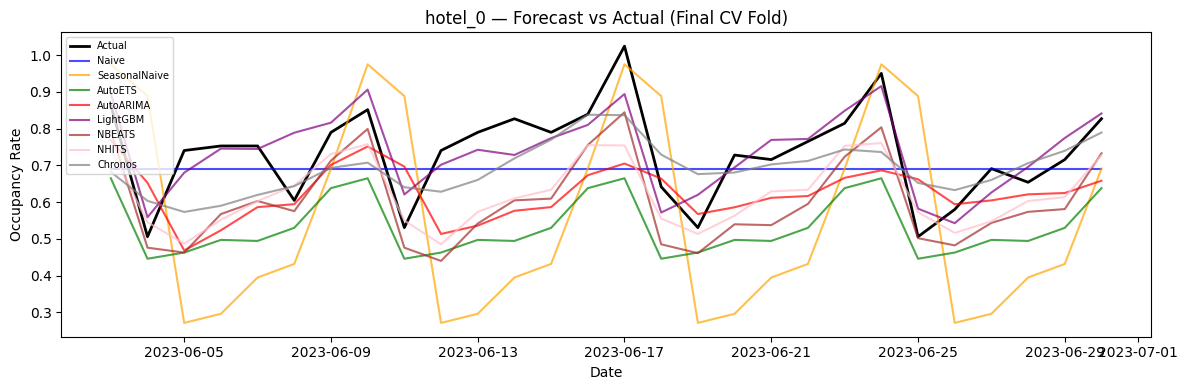

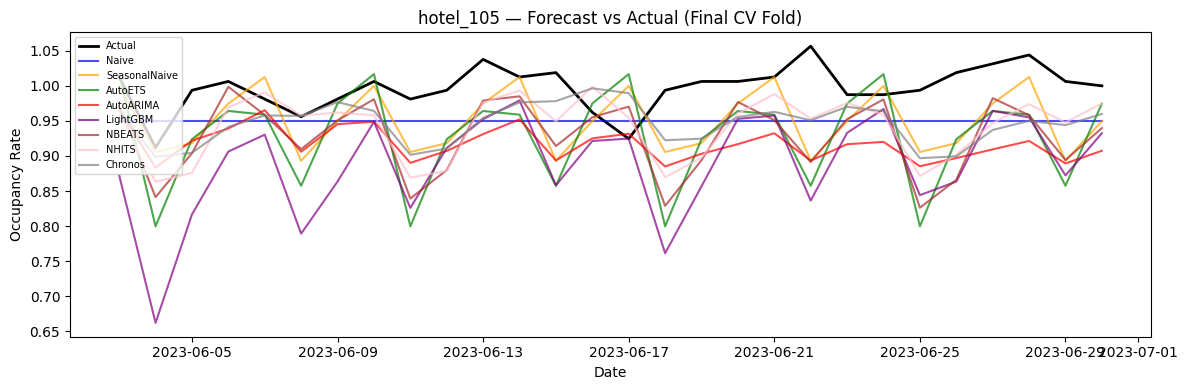

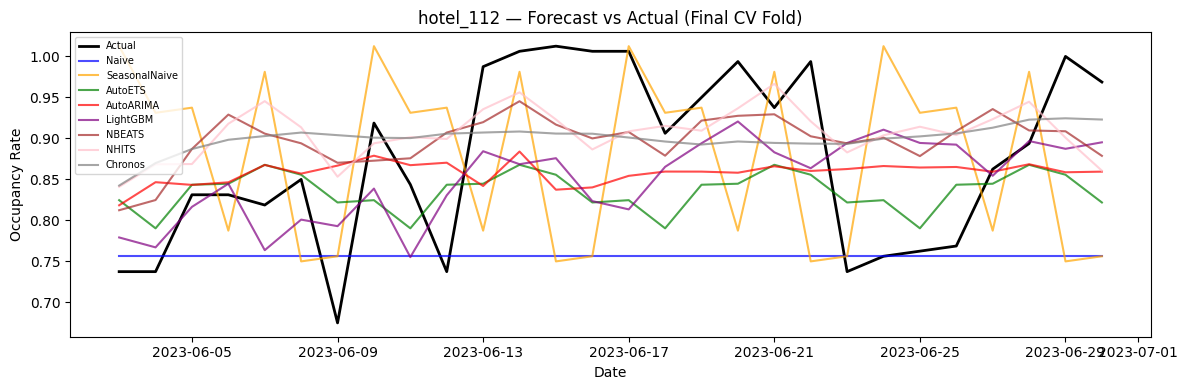

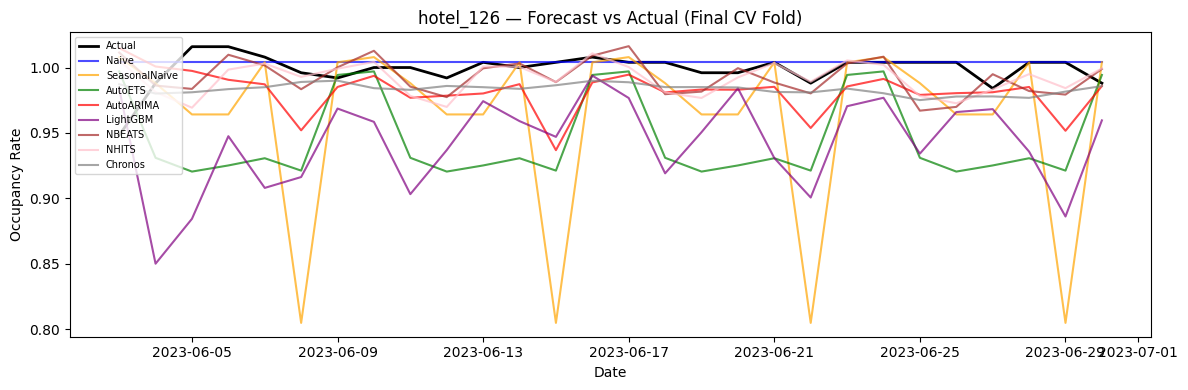

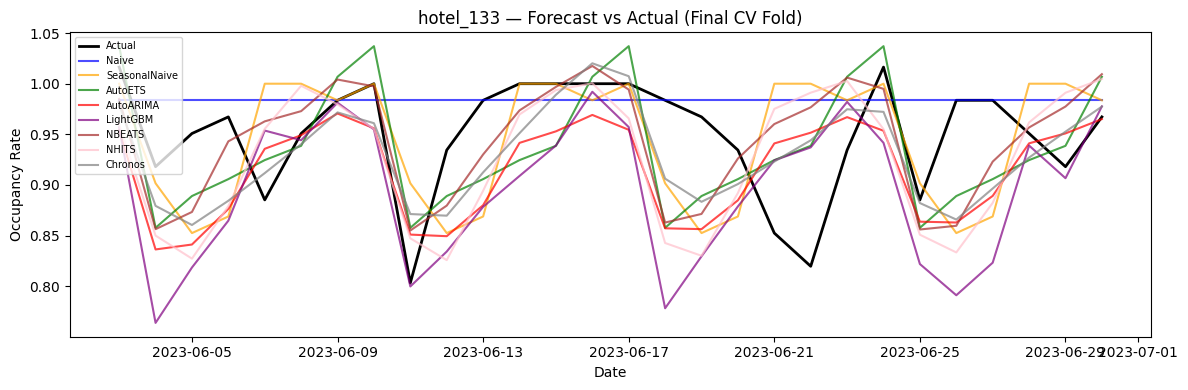

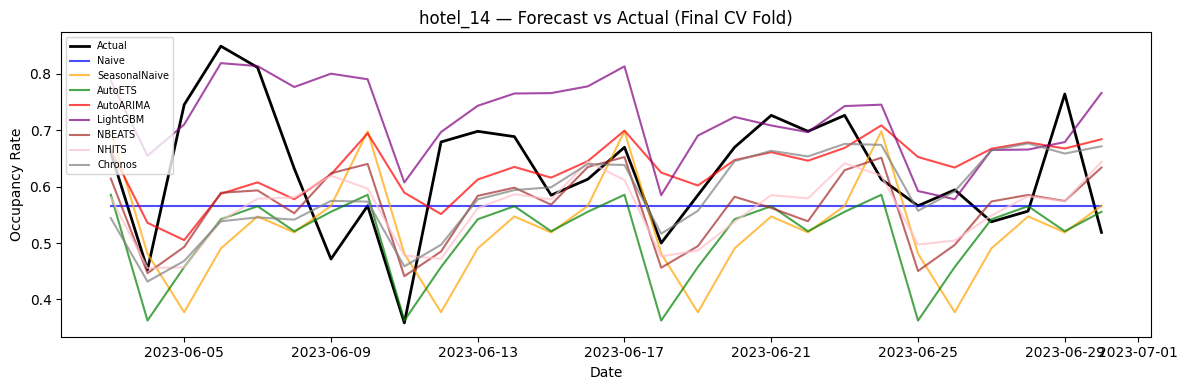

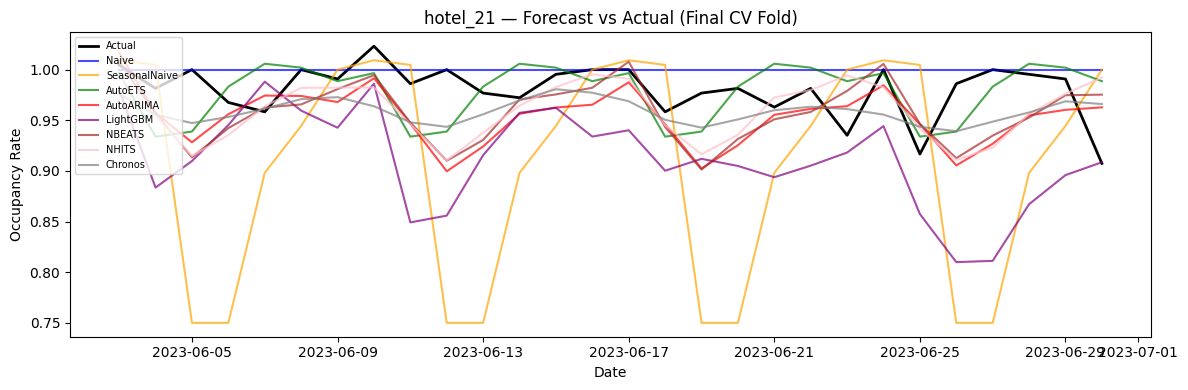

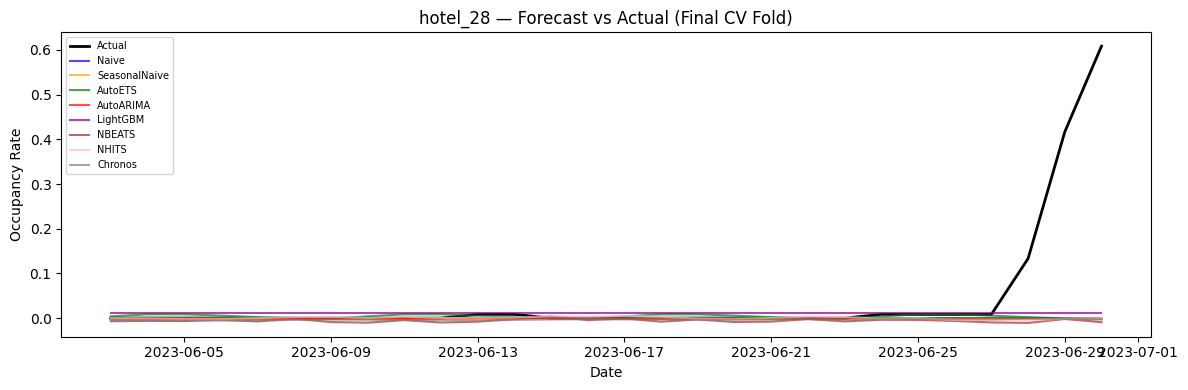

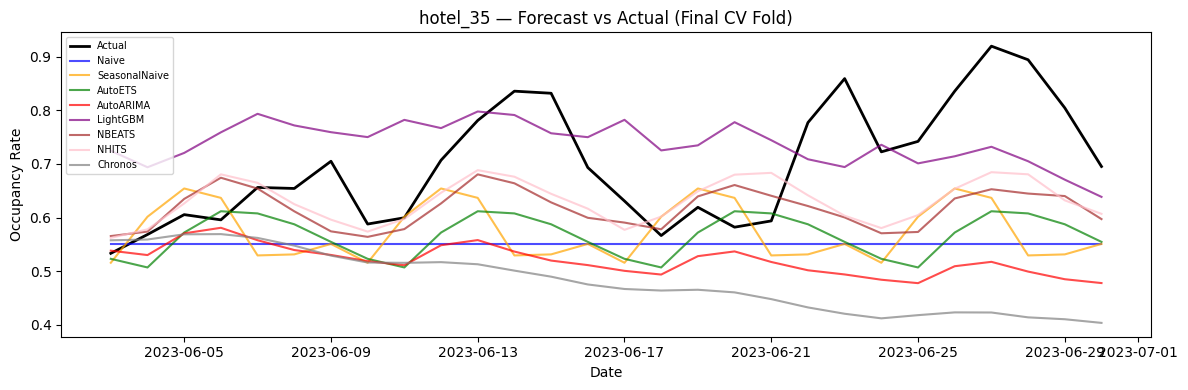

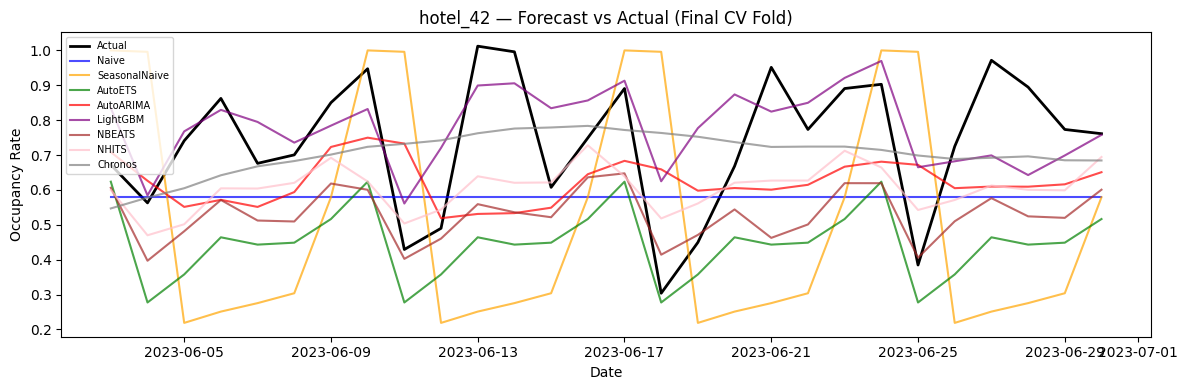

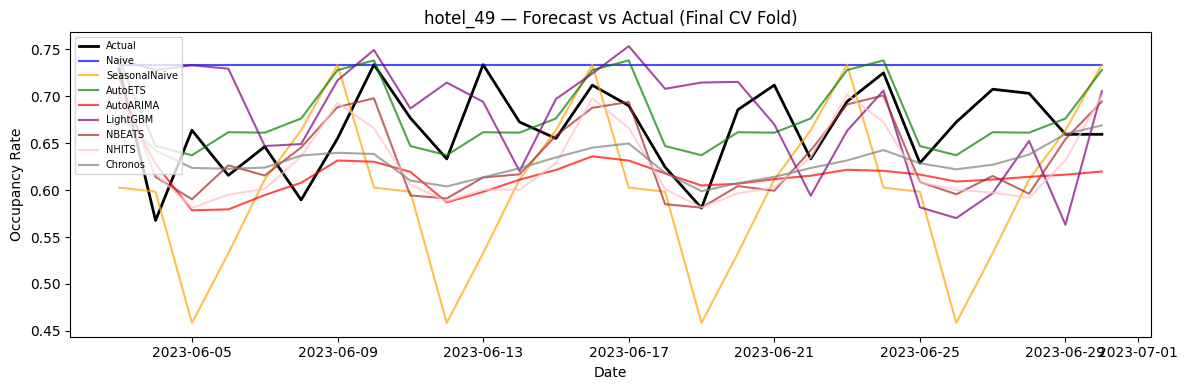

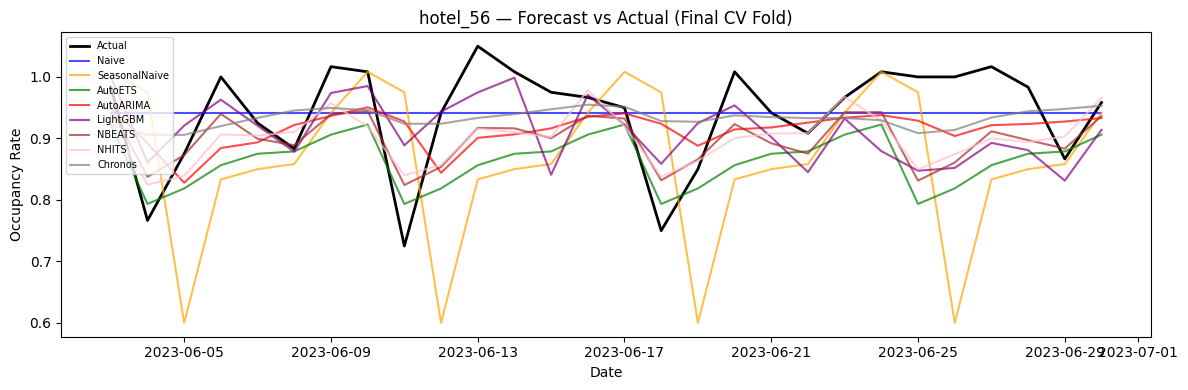

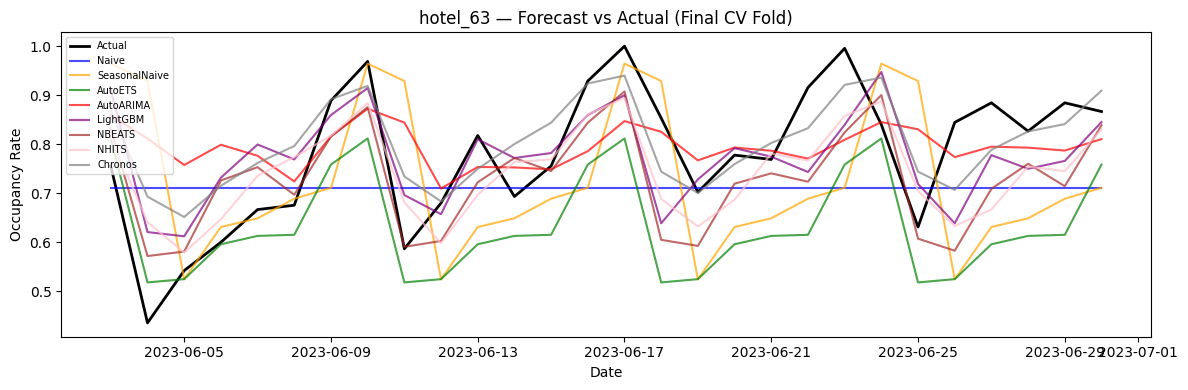

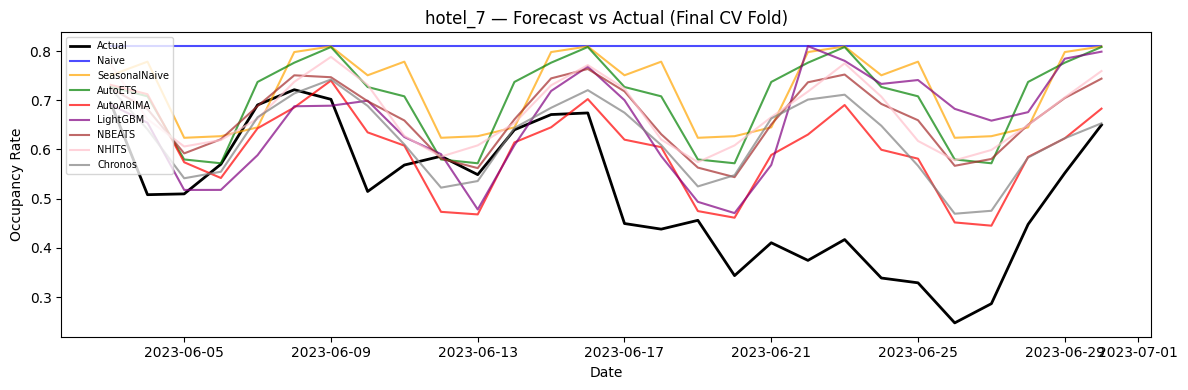

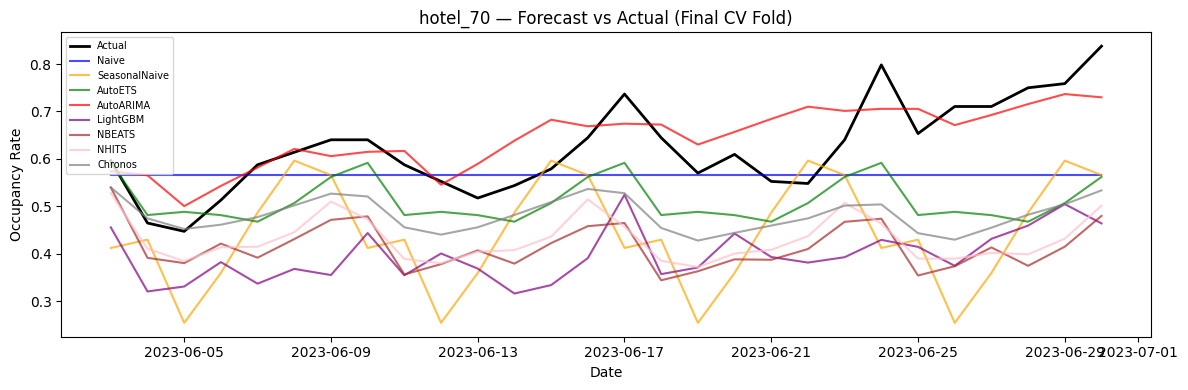

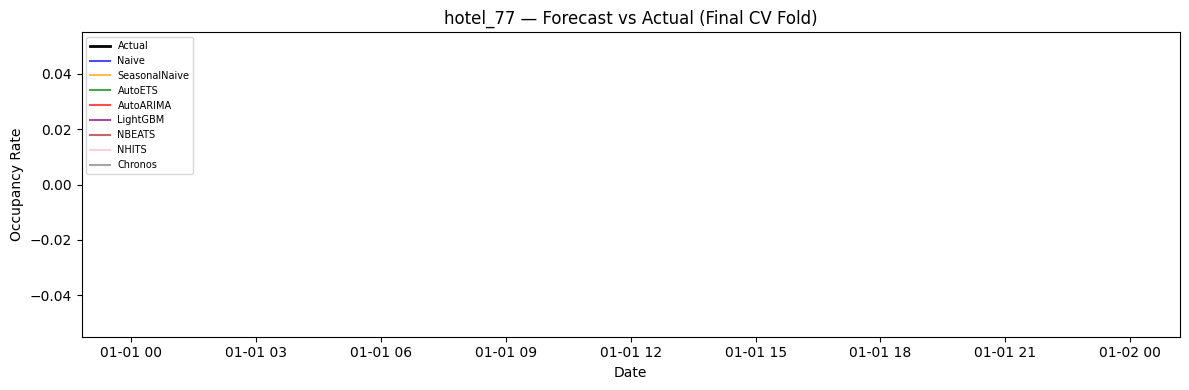

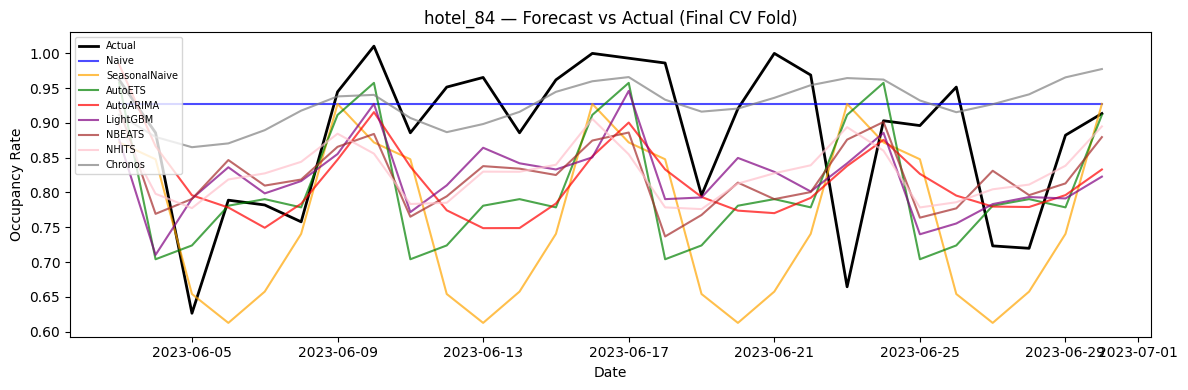

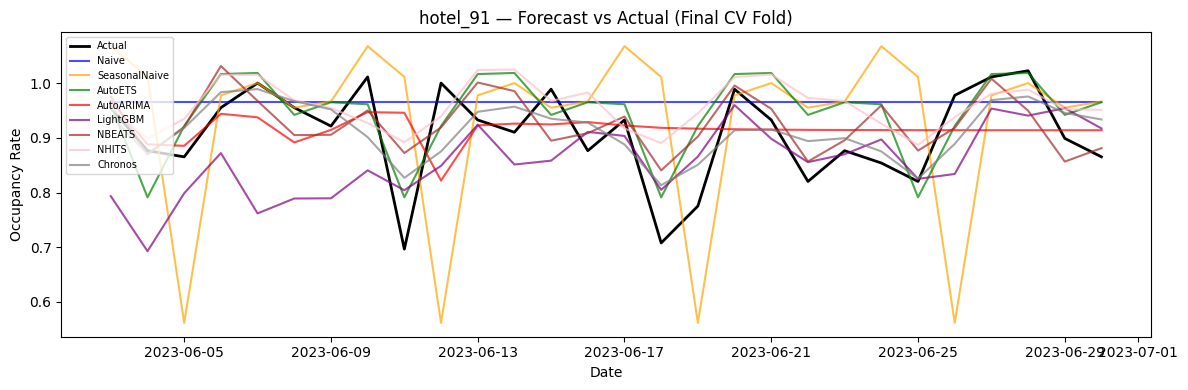

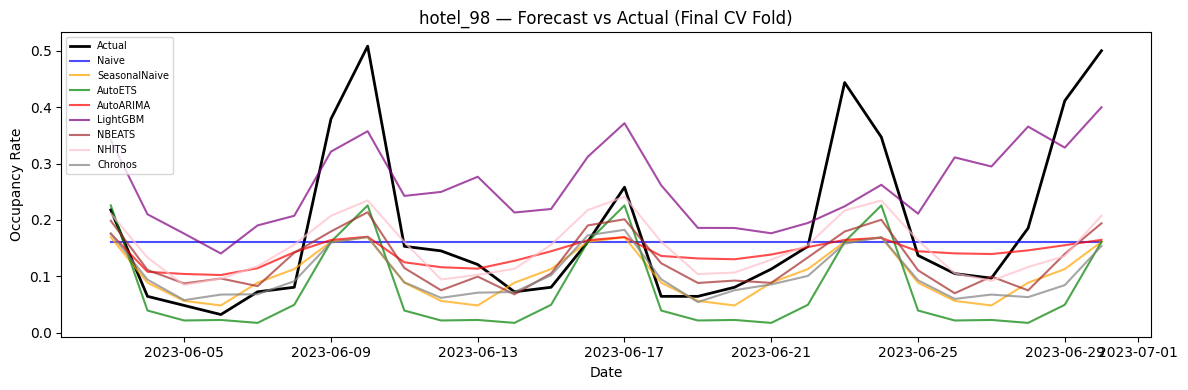

all plots saved


In [37]:
import matplotlib.pyplot as plt

last_cutoff = cv_all['cutoff'].max()
plot_df = cv_all[cv_all['cutoff'] == last_cutoff]

for hotel in ts_df['unique_id'].unique():
    fig, ax = plt.subplots(figsize=(12, 4))
    hotel_plot = plot_df[plot_df['unique_id'] == hotel]

    ax.plot(hotel_plot['ds'], hotel_plot['y'], label='Actual', color='black', linewidth=2)

    colors = ['blue', 'orange', 'green', 'red', 'purple', 'brown', 'pink', 'gray']
    for i, model in enumerate(models):
        ax.plot(hotel_plot['ds'], hotel_plot[model], label=model, alpha=0.7, color=colors[i])

    ax.set_title(f'{hotel} — Forecast vs Actual (Final CV Fold)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Occupancy Rate')
    ax.legend(loc='upper left', fontsize=7)
    plt.tight_layout()
    plt.savefig(f'forecast_plot_{hotel}.png', dpi=100)
    plt.show()

print('all plots saved')

**Save to Drive**

In [38]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

os.makedirs('/content/drive/MyDrive/ISA444_Project', exist_ok=True)

files = [
    'cv_evaluation_results.csv',
    'model_win_counts.csv',
    'final_forecasts_statsforecast.csv',
    'final_forecasts_lightgbm.csv',
    'final_forecasts_neural.csv',
    'final_forecasts_chronos.csv',
] + [f'forecast_plot_{hotel}.png' for hotel in ts_df['unique_id'].unique()]

for f in files:
    shutil.copy(f, f'/content/drive/MyDrive/ISA444_Project/{f}')

print('all files saved to Drive')

Mounted at /content/drive
all files saved to Drive
